IMPORT ALL THE ESSENTIAL LIBRARIES FOR PERFORMING KNN CLASSIFICATION

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

LOAD THE DATASET

In [79]:
df=pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1.0,0.0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1.0,0.0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1.0,0.0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1.0,0.0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0.0,NaN,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1.0,1.0,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1.0,0.0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1.0,0.0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0.0,0.0,110,254,0,0,159,0,0.0,2,0,2,1


age

sex

chest pain type (4 values)

resting blood pressure

serum cholestoral in mg/dl

fasting blood sugar > 120 mg/dl

resting electrocardiographic results (values 0,1,2)

maximum heart rate achieved

exercise induced angina

oldpeak = ST depression induced by exercise relative to rest

the slope of the peak exercise ST segment

number of major vessels (0-3) colored by flourosopy

thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

CHECK WETHER ALL ROWS AND COLUMNS ARE PRESENT IN THE DATA USING HEAD AND TAIL FUNCTIONS

In [80]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1.0,0.0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1.0,0.0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1.0,0.0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1.0,0.0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0.0,NaN,138,294,1,1,106,0,1.9,1,3,2,0


In [81]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1.0,1.0,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1.0,0.0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1.0,0.0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0.0,0.0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1.0,0.0,120,188,0,1,113,0,1.4,1,1,3,0


TO KNOW ABOUT NOTNULL VALUE COUNT OF EACH COLUMN WE USE INFO FUNCTION 

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1024 non-null   float64
 2   cp        1024 non-null   float64
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(3), int64(11)
memory usage: 112.2 KB


DESCRIBE TELLS ABOUT STATS OF DATA

In [83]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1024.000000,1024.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695312,0.943359,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460500,1.029722,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


TO KNOW ABOUT NULL VALUES WE USE ISNULL FUNCTION

In [84]:
df.isnull().sum()

age         0
sex         1
cp          1
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [85]:
df['sex']=df['sex'].fillna(df['sex'].median())

In [86]:
df['cp']=df['cp'].fillna(df['cp'].median())

TO KNOW ABOUT VALUE COUNTS OF DEPENDENT VARIABLE

In [87]:
df['target'].value_counts(())

target
1    526
0    499
Name: count, dtype: int64

TO RENAME COULUMN NAMES WITH EXISTING NAMES WE USE RENAME FUNCTION

In [88]:
df.rename(columns={'cp': 'chest pain type', 'trestbps': 'Yresting blood pressure'}, inplace=True)

UNI VARIATE ANALYSIS

<Axes: title={'center': 'Count Of Heart Patients On Their Age'}, xlabel='age'>

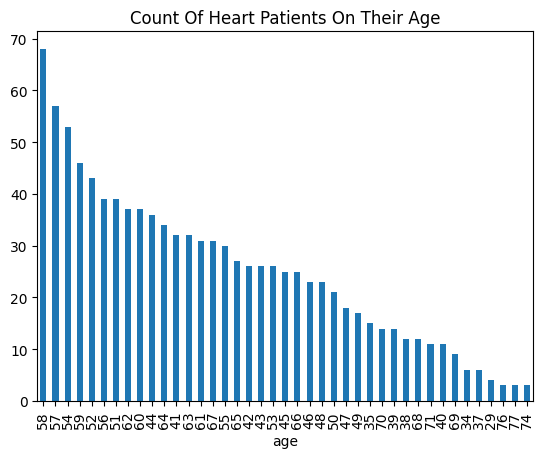

In [89]:
df['age'].value_counts().plot(kind='bar',title= 'Count Of Heart Patients On Their Age')

<Axes: title={'center': 'Count of Patients By Gender '}, xlabel='sex'>

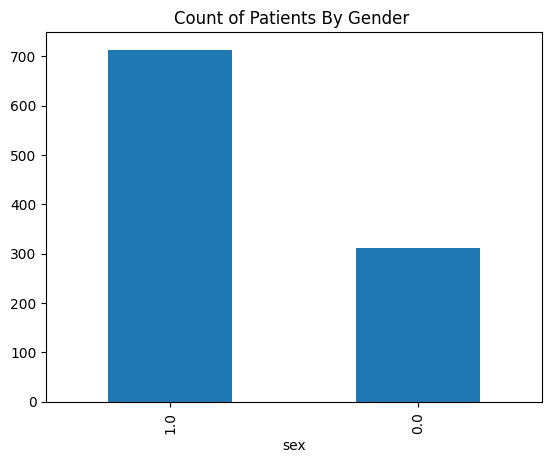

In [90]:
df['sex'].value_counts().plot(kind="bar",title='Count of Patients By Gender ')

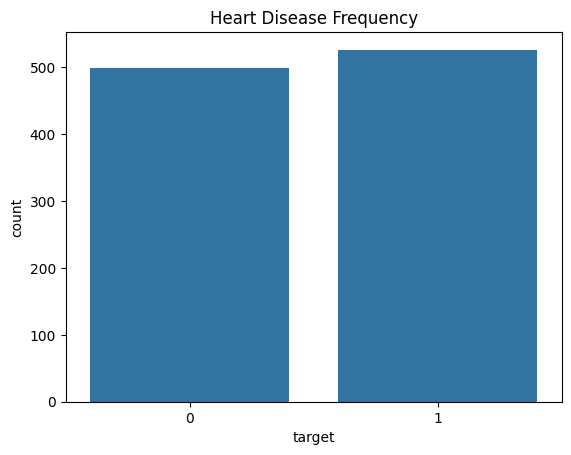

In [91]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Frequency")
plt.show()

BI-VARIATE ANALYSIS

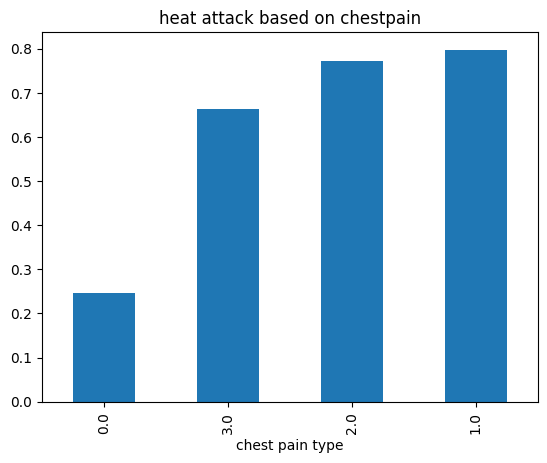

In [92]:
df.groupby('chest pain type')['target'].mean().sort_values().plot(
    kind='bar', title="heat attack based on chestpain"
)
plt.show()


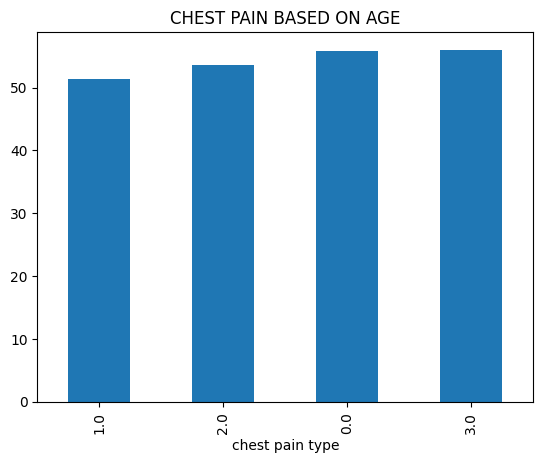

In [93]:
df.groupby('chest pain type')['age'].mean().sort_values().plot(
    kind='bar', title="CHEST PAIN BASED ON AGE"
)
plt.show()

MULTIVARIATE ANALYSIS

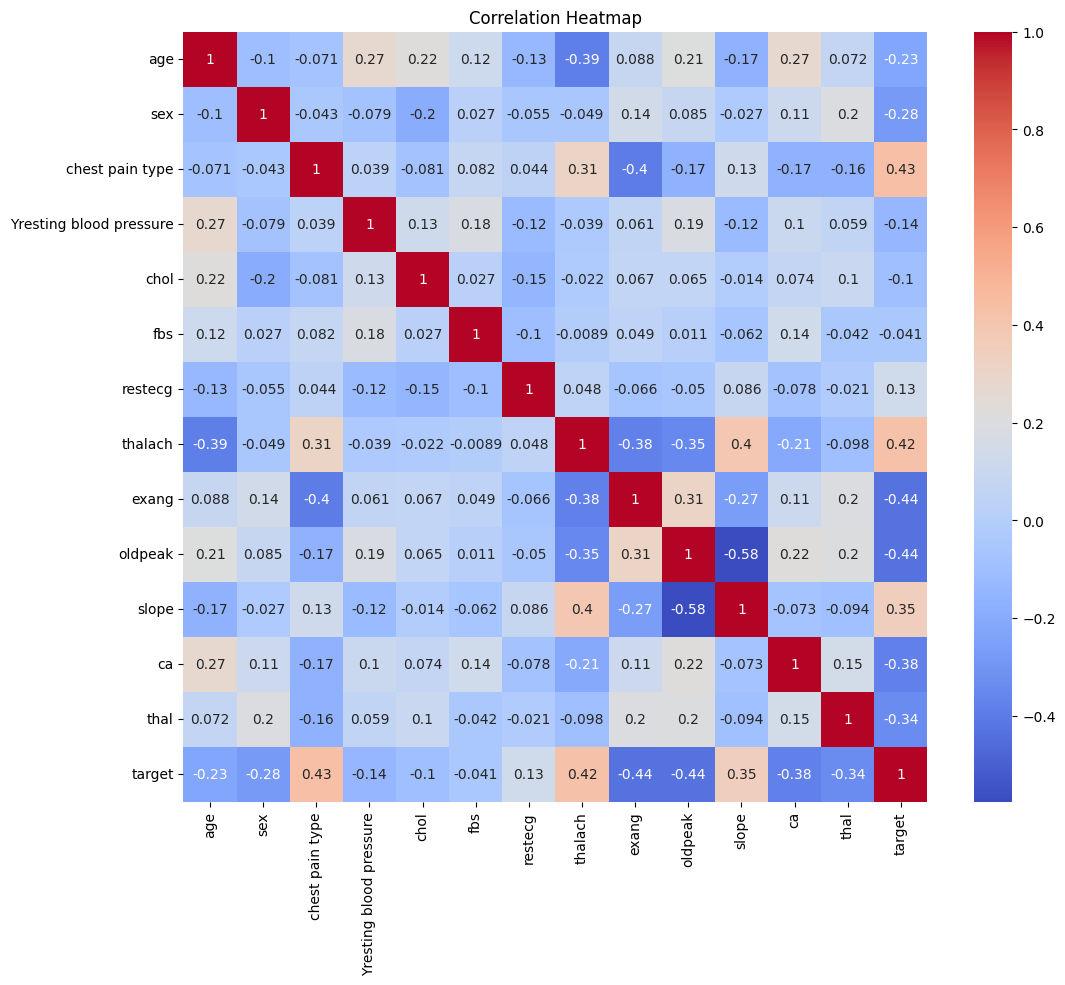

In [94]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

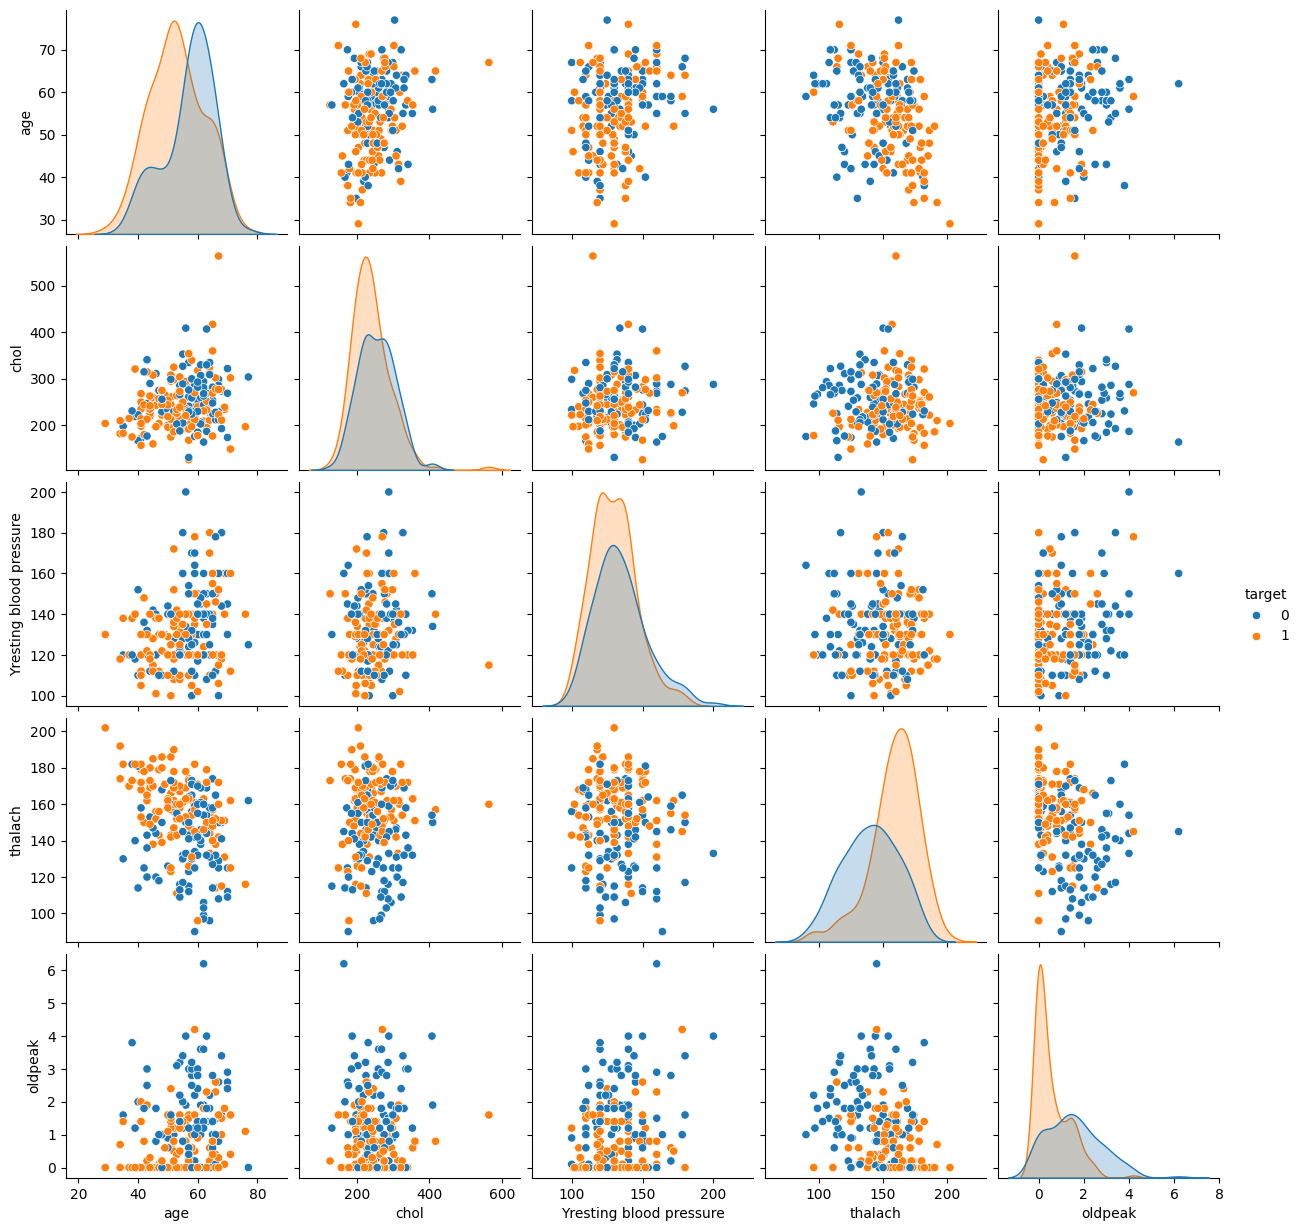

In [95]:
sns.pairplot(df.sample(300), vars=['age','chol','Yresting blood pressure','thalach','oldpeak'], hue='target')
plt.show()

TO REPLACE OR MINIMIZE THE OUTLIERS THAT ARE PRESENT IN DATA WE USE THIS IQR FORMULA

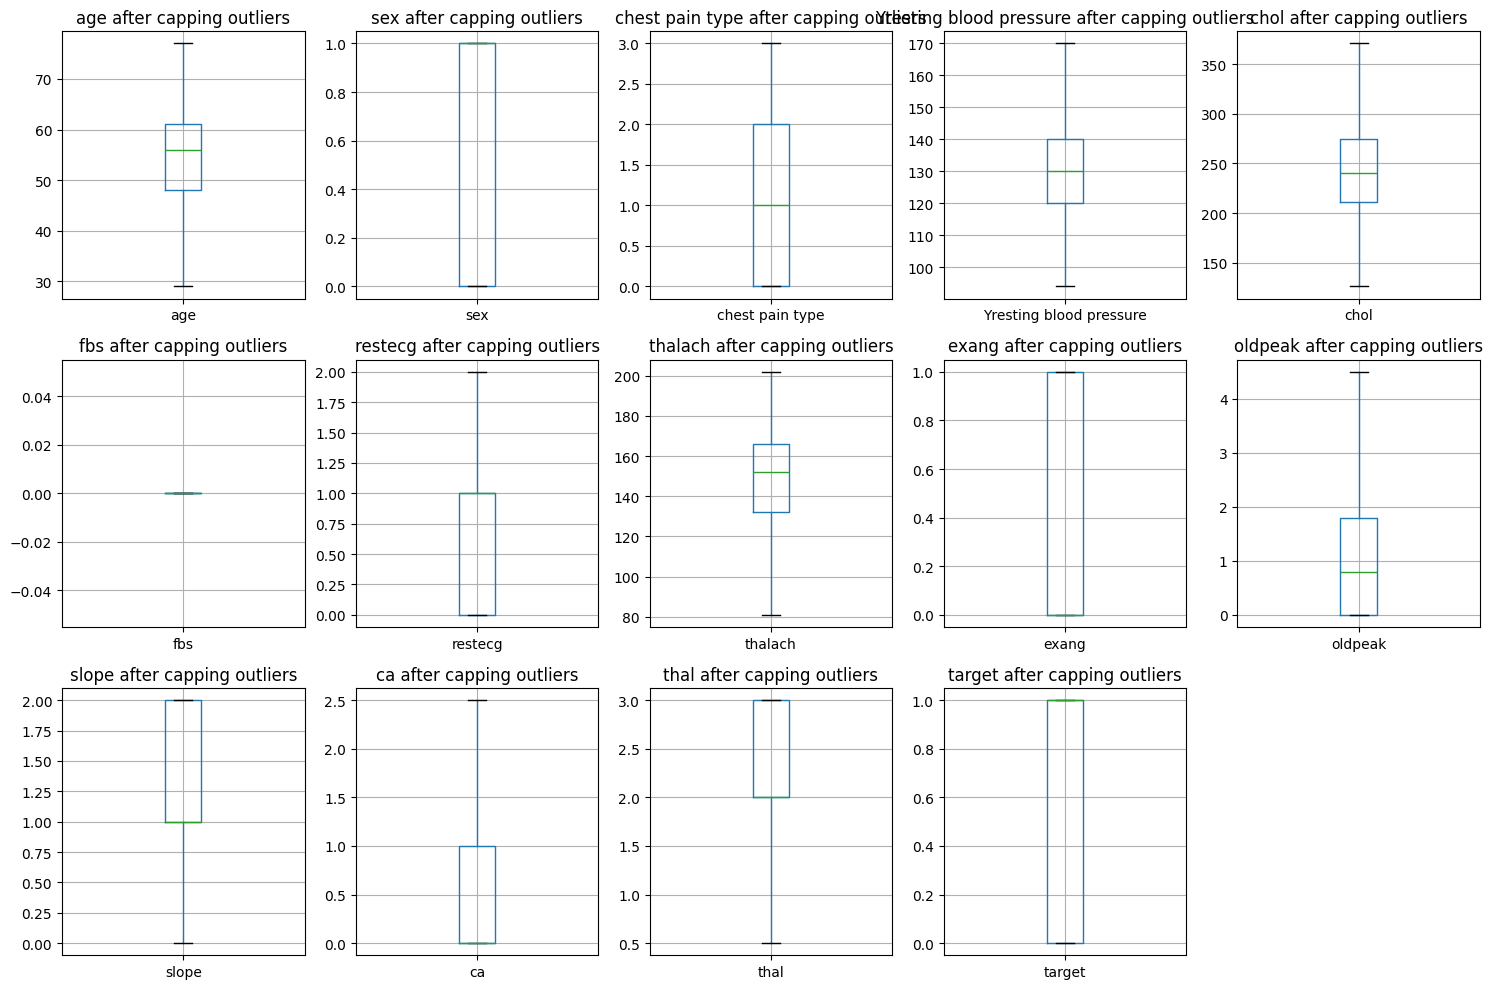

In [96]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

columns_to_cap = ["age", "sex", "chest pain type", "Yresting blood pressure", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
for col in columns_to_cap:
    cap_outliers(df, col)

# Checking the boxplots again to confirm outlier treatment
plt.figure(figsize=(15, 10))
for i, col in enumerate(columns_to_cap, 1):
    plt.subplot(3, 5, i)
    df.boxplot(column=col)
    plt.title(f'{col} after capping outliers')

plt.tight_layout()
plt.show()    

In [97]:
df

,age,sex,chest pain type,Yresting blood pressure,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1.0,0.0,125.0,212.0,0.0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1.0,0.0,140.0,203.0,0.0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1.0,0.0,145.0,174.0,0.0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1.0,0.0,148.0,203.0,0.0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0.0,1.0,138.0,294.0,0.0,1,106.0,0,1.9,1,2.5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1.0,1.0,140.0,221.0,0.0,1,164.0,1,0.0,2,0.0,2.0,1
1021,60,1.0,0.0,125.0,258.0,0.0,0,141.0,1,2.8,1,1.0,3.0,0
1022,47,1.0,0.0,110.0,275.0,0.0,0,118.0,1,1.0,1,1.0,2.0,0
1023,50,0.0,0.0,110.0,254.0,0.0,0,159.0,0,0.0,2,0.0,2.0,1


AFTER DATA CLEANING ITS TIME TO SEPERATE INDEPENDENT VARIABLES AND DEPENDENT VARIABLES 

In [98]:
x=df.drop('target',axis=1)
y=df['target']

AFTER DATA SEPERATION WE HAVE NOW SOME CLEANED DATA NOW ITS TIME TO TRANSFORM THE CLUMSY DATA

SCALING WITH MINMAXSCALER

In [99]:
model=MinMaxScaler()
model.fit(x)
x=model.transform(x)

In [100]:
x[0:]

array([[0.47916667, 1.        , 0.        , ..., 1.        , 0.8       ,
        1.        ],
       [0.5       , 1.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.85416667, 1.        , 0.        , ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.375     , 1.        , 0.        , ..., 0.5       , 0.4       ,
        0.6       ],
       [0.4375    , 0.        , 0.        , ..., 1.        , 0.        ,
        0.6       ],
       [0.52083333, 1.        , 0.        , ..., 0.5       , 0.4       ,
        1.        ]], shape=(1025, 13))

AFTER SCALING THE DATA GETS SCALED SO ITS TIME TO SEPERATE TRAIN,TEST SIZE OF DATA USING TRAIN_TEST_SPLIT

In [101]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(820, 13)
(205, 13)
(820,)
(205,)


AFTER SEPERATING TRAINING AND TESTING DATA WE NEED TO GIVE DATA TO MODEL IN THIS WE USE K NEAREST NEIGHBOUR CLASSIFICATION

In [102]:
from sklearn.neighbors import NearestNeighbors


knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


AFTER MODEL GETS TRAINED WITH X,Y TRAIN DATA ITS TIME TO PERFORM EVALUATION WITH X_TEST IT BECOMES THE Y_PREDICTION

In [103]:
y_pred=knn.predict(x_test)
print(y_pred)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0
 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 1
 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 0]


CHECK DIFFERENCE BETWEEN Y_TEST AND Y_PRED

In [104]:
y_test[0:20]

527    1
359    1
447    0
31     1
621    0
590    1
905    0
737    0
76     1
948    0
432    1
70     0
680    1
101    1
845    0
656    0
310    0
344    1
837    1
174    0
Name: target, dtype: int64

In [105]:
y_pred[0:20]

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0])

WE HAVE SEEN HOW DATA GETS PREDICTED NOW ITS TIME TO CHECK ACCURACY SCORE OF TRAING AND TESTING DATA

In [106]:
print(accuracy_score(y_test,y_pred))

0.9219512195121952


In [107]:
knn.score(x_train,y_train)

0.9926829268292683

In [108]:
knn.score(x_test,y_test)

0.9219512195121952

WE HAVE SEEN TRAING AND TESTING SCORE WITH K VALUE 3 TO GET GOOD ACCURATE SCORE WE NEED TO HYPER TUNE WITH K VALUE TO SEE GOOD ACCURACY SCORE

In [109]:
for i in range(3,51,2):
    print(f'k = {i}')
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    print("Train Score:",knn.score(x_train, y_train))
    print("Test Score:",knn.score(x_test, y_test))
    print('------------------------')

k = 3
Train Score: 0.9926829268292683
Test Score: 0.9219512195121952
------------------------
k = 5
Train Score: 0.9536585365853658
Test Score: 0.8390243902439024
------------------------
k = 7
Train Score: 0.9146341463414634
Test Score: 0.8439024390243902
------------------------
k = 9
Train Score: 0.8926829268292683
Test Score: 0.8341463414634146
------------------------
k = 11
Train Score: 0.8780487804878049
Test Score: 0.8195121951219512
------------------------
k = 13
Train Score: 0.8792682926829268
Test Score: 0.8292682926829268
------------------------
k = 15
Train Score: 0.8768292682926829
Test Score: 0.8292682926829268
------------------------
k = 17
Train Score: 0.8792682926829268
Test Score: 0.8341463414634146
------------------------
k = 19
Train Score: 0.8634146341463415
Test Score: 0.8390243902439024
------------------------
k = 21
Train Score: 0.8573170731707317
Test Score: 0.8341463414634146
------------------------
k = 23
Train Score: 0.8670731707317073
Test Score: 0.8

THIS ERROR RATE IS TO KNOW THE DIFFERNCE BETWEEN OUR TEST VALUES VS PREDICTED VALUE

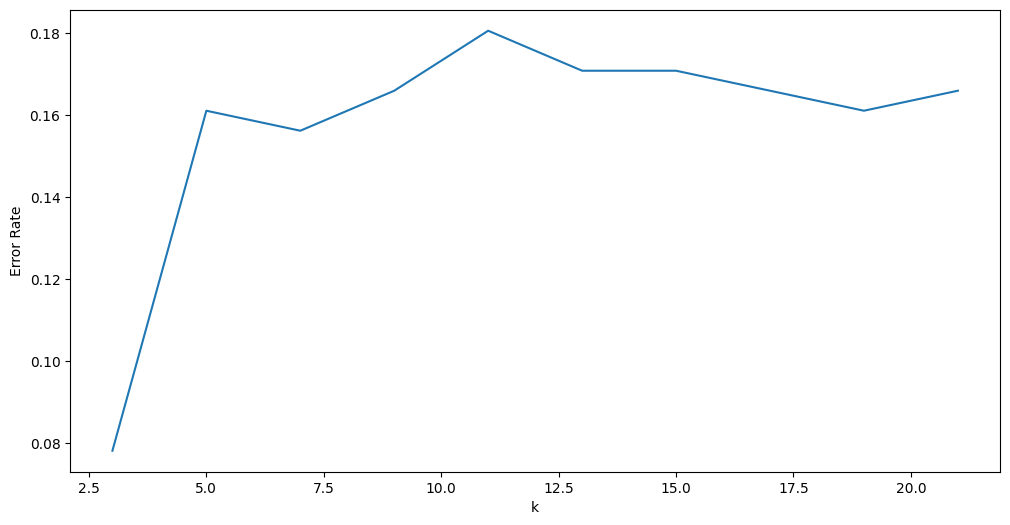

In [110]:

error_rate = []
for i in range(3,22,2):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    error_rate.append(np.mean(y_pred != y_test))
plt.figure(figsize=(12,6))
plt.plot(range(3,22,2),error_rate)
plt.xlabel('k')
plt.ylabel('Error Rate')
plt.show()

THIS IS THE TOTAL ACCURACY 

In [111]:

print(accuracy_score(y_test, y_pred)*100,"% Accuracy")

83.41463414634146 % Accuracy


CONFUSION MATRIX

In [112]:
pd.crosstab(y_test,y_pred)

col_0,0,1
target,,
0,78,24
1,10,93


CLASSIFICATION REPORT FOR THE  HEART DATA 

In [113]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82       102
           1       0.79      0.90      0.85       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



evaluate a machine learning model's performance in classification tasks. Accuracy is the overall correct predictions out of total predictions, while precision measures the proportion of true positives among all positive predictions, and recall measures the proportion of actual positives that were correctly identified. The F1 score is the harmonic mean of precision and recall, providing a single metric that balances the two, and is particularly useful for imbalanced datasets

In [114]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8341463414634146
Confusion Matrix:
 [[78 24]
 [10 93]]


CUNFUSION MATRIX FOR THE DATA

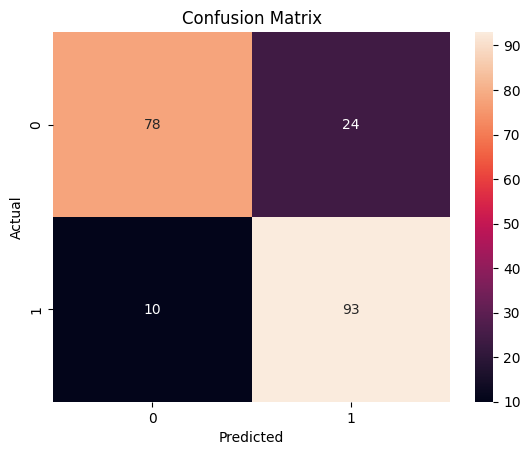

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

COMPARING WITH OTHER MODELS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score



# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Random Forest
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Print results
print("Model Comparison:")

print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")

Model Comparison:
Logistic Regression Accuracy: 80.98%
Random Forest Accuracy: 98.54%


CHECKING WHY RANDOM FOREST GOT HIGH ACCURACY IT MAY OVERFIT

In [121]:
print("Train Accuracy RF:", rf.score(x_train, y_train))
print("Test Accuracy RF:", rf.score(x_test, y_test))

Train Accuracy RF: 1.0
Test Accuracy RF: 0.9853658536585366


OPTIMIZING THE RANDOM FOREST MODEL

In [122]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

OPTIMIZED RESULT

In [123]:
rf.fit(x_train, y_train)
print("Train Accuracy:", rf.score(x_train, y_train))
print("Test Accuracy:", rf.score(x_test, y_test))

Train Accuracy: 0.9512195121951219
Test Accuracy: 0.848780487804878


CROSS VALIDATION FOR RANDOM FOREST

In [124]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, x, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9014634146341463
